# λ_p Sweep — Pearson Correlation Analysis

Analyses `data/lambda_p_sweep_test.csv`: 6 runs swept over λ_p.

The CSV stores 8 metrics per run (groups of 8 rows). We pivot it so each run
is a single row, then compute the full Pearson correlation matrix across all
numeric columns (det and stoch means, plus their stds where available).

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130

## 1  Load and reshape the CSV

The CSV repeats the same 8 metric names for each run.  
We assign a `run` index, then pivot to wide format.

In [14]:
METRICS_PER_RUN = 8

# Assumed lambda_p values for the 6 runs (edit if the true sweep differs).
LAMBDA_P_VALUES = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]

CSV_PATH = Path("../data/lambda_p_sweep_test.csv")

raw = pd.read_csv(CSV_PATH)

# Replace '—' (missing std for success_rate) with NaN and cast numerics.
raw = raw.replace("—", np.nan)
for col in ["det_mean", "det_std", "stoch_mean", "stoch_std"]:
    raw[col] = pd.to_numeric(raw[col])

# Assign a run index based on groups of METRICS_PER_RUN rows.
raw["run"] = raw.index // METRICS_PER_RUN
raw["lambda_p"] = raw["run"].map(dict(enumerate(LAMBDA_P_VALUES)))

raw.head(16)

,metric,det_mean,det_std,stoch_mean,stoch_std,run,lambda_p
0,success_rate,0.562,NaN,0.375,NaN,0,0.01
1,return,93.053,90.152,56.786,89.130,0,0.01
2,episode_length,235.688,272.583,201.688,206.216,0,0.01
3,path_adherence,0.351,0.211,0.407,0.288,0,0.01
4,exploration,0.031,0.022,0.019,0.013,0,0.01
5,risk_exposure,0.025,0.028,0.041,0.042,0,0.01
6,final_hp,100.000,0.000,100.000,0.000,0,0.01
7,final_resources,58.562,35.840,63.625,38.751,0,0.01
8,success_rate,0.438,NaN,0.750,NaN,1,0.05
9,return,199.057,126.860,265.561,107.830,1,0.05


In [15]:
# Pivot: one row per run, columns = metric×stat combinations.
value_cols = ["det_mean", "det_std", "stoch_mean", "stoch_std"]

wide = raw.pivot_table(
    index=["run", "lambda_p"],
    columns="metric",
    values=value_cols,
    aggfunc="first",
)

# Flatten MultiIndex columns: stat_metric  (e.g. det_mean_return)
wide.columns = [f"{stat}_{metric}" for stat, metric in wide.columns]
wide = wide.reset_index()

print(wide.shape)
wide

(6, 32)


,run,lambda_p,det_mean_episode_length,det_mean_exploration,det_mean_final_hp,det_mean_final_resources,det_mean_path_adherence,det_mean_return,det_mean_risk_exposure,det_mean_success_rate,...,stoch_mean_return,stoch_mean_risk_exposure,stoch_mean_success_rate,stoch_std_episode_length,stoch_std_exploration,stoch_std_final_hp,stoch_std_final_resources,stoch_std_path_adherence,stoch_std_return,stoch_std_risk_exposure
0,0,0.01,235.688,0.031,100.0,58.562,0.351,93.053,0.025,0.562,...,56.786,0.041,0.375,206.216,0.013,0.0,38.751,0.288,89.130,0.042
1,1,0.05,189.562,0.024,100.0,45.081,0.456,199.057,0.039,0.438,...,265.561,0.022,0.750,118.551,0.012,0.0,26.614,0.277,107.830,0.022
2,2,0.10,360.062,0.027,100.0,51.938,0.368,61.049,0.024,0.438,...,23.964,0.023,0.250,371.770,0.019,0.0,25.428,0.254,74.528,0.020
3,3,0.20,411.812,0.026,100.0,58.938,0.341,41.782,0.031,0.312,...,61.668,0.014,0.438,396.682,0.024,0.0,27.388,0.225,88.128,0.012
4,4,0.50,234.312,0.027,100.0,53.544,0.380,105.354,0.035,0.562,...,88.938,0.024,0.500,96.143,0.009,0.0,33.737,0.268,97.644,0.022
5,5,1.00,219.438,0.027,100.0,38.575,0.403,134.914,0.017,0.625,...,153.253,0.011,0.688,96.310,0.013,0.0,29.707,0.312,89.256,0.007


## 2  Pearson correlation matrix

Only `det_mean` columns are kept (stoch and std variants dropped, `final_hp` excluded).
Includes `lambda_p` so we can see which metrics co-vary with the sweep parameter.

In [16]:
# Keep only det_mean columns (drop stoch and std variants) and drop final_hp.
num_cols = [
    c for c in wide.select_dtypes(include=np.number).columns
    if c != "run"
    and not c.startswith("det_std")
    and not c.startswith("stoch_")
    and not c.endswith("_final_hp")
]
corr = wide[num_cols].corr(method="pearson")

# Pretty-print sorted by |correlation with lambda_p|.
corr_lp = corr["lambda_p"].drop("lambda_p").sort_values(key=abs, ascending=False)
print("Correlation with lambda_p (sorted by |r|):")
print(corr_lp.to_string())

Correlation with lambda_p (sorted by |r|):
det_mean_final_resources   -0.652015
det_mean_success_rate       0.591881
det_mean_risk_exposure     -0.503094
det_mean_episode_length    -0.265439
det_mean_return             0.149547
det_mean_path_adherence     0.145785
det_mean_exploration       -0.071352


## Full correlation heatmap

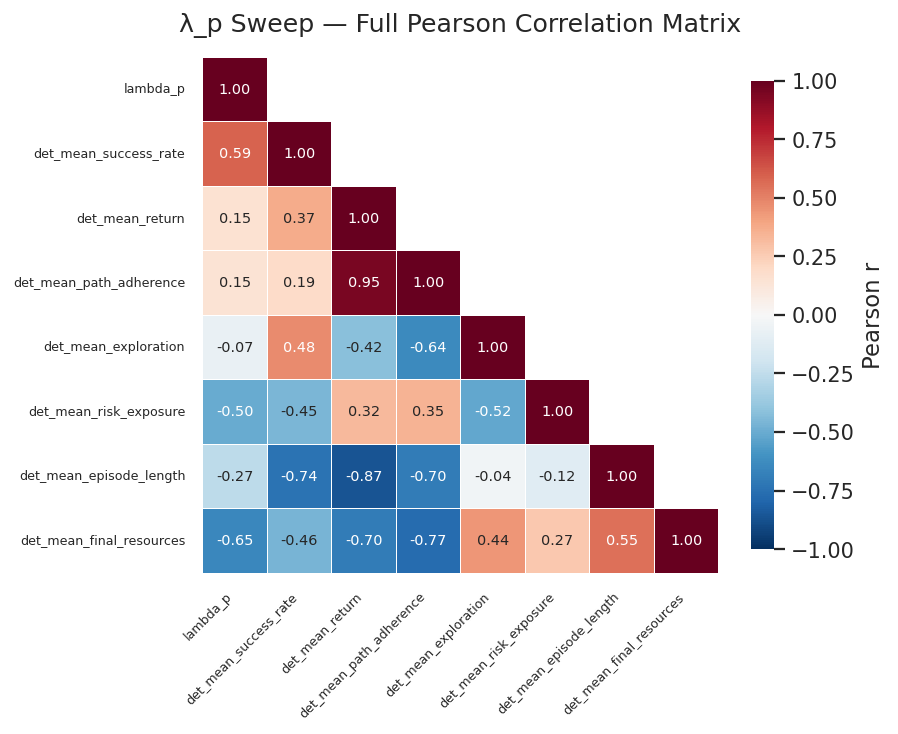

In [17]:
PRIORITY_METRICS = [
    "lambda_p",
    "success_rate",
    "return",
    "path_adherence",
    "exploration",
    "risk_exposure",
]

def _metric_sort_key(col):
    for rank, m in enumerate(PRIORITY_METRICS):
        if col == m or col.endswith(f"_{m}"):
            return (rank, col)
    return (len(PRIORITY_METRICS), col)

ordered_cols = sorted(corr.columns, key=_metric_sort_key)
corr_ordered = corr.loc[ordered_cols, ordered_cols]

n = len(corr_ordered)
fig, ax = plt.subplots(figsize=(max(7, n * 0.25), max(7, n * 0.25)))

mask = np.triu(np.ones_like(corr_ordered, dtype=bool), k=1)  # lower triangle + diagonal

sns.heatmap(
    corr_ordered,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.6, "label": "Pearson r"},
)

ax.set_title("λ_p Sweep — Full Pearson Correlation Matrix", fontsize=14, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

## correlations with λ_p only

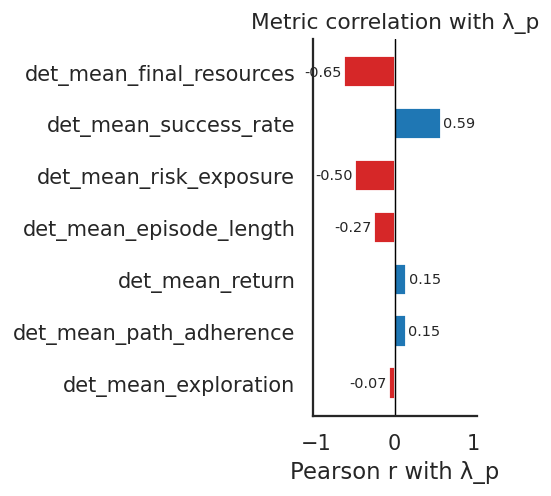

In [18]:
fig, ax = plt.subplots(figsize=(4, max(4, len(corr_lp) * 0.38)))

colors = ["#d62728" if v < 0 else "#1f77b4" for v in corr_lp.values]
bars = ax.barh(corr_lp.index[::-1], corr_lp.values[::-1], color=colors[::-1], height=0.6)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Pearson r with λ_p")
ax.set_title("Metric correlation with λ_p", fontsize=12)

for bar, val in zip(bars, corr_lp.values[::-1]):
    offset = 0.03 if val >= 0 else -0.03
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha=ha, fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()